# SCOUT Overview

## Overview

This vignette demonstrates the basics of how to use SCOUT. We: 
1. Simulate single-cell lineage trees with gene expression data
2. Fit evolutionary models (BM1, OU1, OUM) to the simulated data
3. Perform model selection and recover known parameters

The simulation framework allows you to test SCOUT's ability to distinguish between different evolutionary processes and accurately estimate parameters.

### Installing required libraries

If you don't have the following libraries installed you can do so here:

In [ ]:
# Generally don't run this cell unless you need to
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("ComplexHeatmap")
BiocManager::install("ggtree")

install.packages("future")
install.packages("progressr")
install.packages("future.apply")
install.packages("tidyverse")
install.packages("ape")
install.packages("paleotree")
install.packages("nloptr")
install.packages("Matrix")
install.packages("corpcor")

### Load the libraries and SCOUT

In [2]:
suppressWarnings(suppressPackageStartupMessages({
    library(SCOUT)
    library(ComplexHeatmap)
    library(ggtree)
    library(future)
    library(progressr)
    library(future.apply)
    library(tidyverse)
    library(corpcor)
    library(paleotree)
    library(nloptr)
}))

## Theoretical Background: The Ornstein-Uhlenbeck Process

The Ornstein-Uhlenbeck (OU) process models trait evolution with selection toward an optimum:

$$dX(t) = \alpha[\theta - X(t)]dt + \sigma dW(t)$$

Where:
- **α (alpha)**: Selection strength - how strongly the trait is pulled toward the optimum
  - α = 0: No selection (equivalent to Brownian Motion)
  - α > 0: Stronger selection toward optimum
- **θ (theta)**: Optimal trait value - the value toward which selection pulls
- **σ² (sigma²)**: Stochastic motion parameter - represents random drift
- **W(t)**: Wiener process (Brownian motion)

### Models in SCOUT:

1. **BM1** (Brownian Motion): α = 0, constant σ² across tree
2. **OU1** (Single OU): Single α, θ, and σ² for entire tree
3. **OUX** (Multiple Optima OU): Single α and σ², but different θ values for different regimes

## Step 1: Simulate Test Data

We'll generate a synthetic dataset with:
- **30 genes per evolutionary regime** (BM1, OU1, OUM)
- **128 cells** arranged in a lineage tree
- **Multiple parameter combinations** to test SCOUT's ability to discriminate between different evolutionary dynamics

### Simulation Parameters:

- `ngenes`: Number of genes to simulate per regime (30)
- `ncells`: Number of cells in the lineage tree (128)
- `tree`: Cell state tree topology in Newick format. The tree defines the number of evolutionary regimes/states. For example: `'(((t1:0.5,t2:0.5):0.5,(t3:0.5,t4:0.5):0.5):0.5);'` creates 4 states
- `a`: Selection strength (α) values to test: [0.5, 1.0, 1.5]
- `s`: Stochastic parameter (σ) values to test: [0.1, 0.5, 1.0]
- `t0`: Initial theta (optimum) value (3.0)
- `theta_step`: How much theta differs between regimes (1.0)
- `nevfs`: Number of expression variance factors for SymSim pipeline (10)

### Indel-Tree Simulator 

In [7]:
# Simulate test data with multiple parameter combinations
sim.res <- simulate_test_data(ngenes = 30, # number of genes to simulat per regime.  
                              ncells = 128, # number of cells to simulate. # genes < # cells 
                              tree ='((t3:1, t4:1):1);', # cell state tree 
                              outdir = './simulate_data', # output directory 
                              out_prefix = 'sim_test', # prefix for output files 
                              param_mode = 'affine', 
                              a = c(0.5, 1, 1.5), # alpha parameters to simulate
                              s = c(0.1, 0.5, 1), # sigma parameters to simulate 
                              t0 = 3,  # initial theta value for OUwie.sim 
                              theta_step = 2, # for multiple theta values, how offset should the different regimes be. 
                              nevfs = 10) # number of EVFs to generate (for SymSim pipeline)



2026-10-02 15:31:49.223782 | Generating scLT data for 128 cells.

2026-10-02 15:31:49.225195 | Files will be saved to ./simulate_data.



Directory already exists: ./simulate_data 


Warning message in cbind(...):
“number of rows of result is not a multiple of vector length (arg 3)”
2026-10-02 15:32:42.777455 | Simulating OU genes for 9 parameter combinations.

2026-10-02 15:32:53.020762 | Data generation complete



### Continuous-Time Simulator 

In [9]:
P <- matrix(c(0.90, 0.08, 0.02,
                0.10, 0.80, 0.10,
                0.02, 0.08, 0.90), nrow = 3, byrow = TRUE)
                
ncells <- 256 
hbd_tree <- simulate_tree_states(P, ncells = ncells,
                                   birth_rate = 1, death_rate = 0, rho = 1,  # castor hbd parameters
                                   seed = 1) 
table(hbd_tree$states)           
# 2. Simulate BM1 / OU1 / OUM genes and counts on this tree 
outdir <- './simulate_data_hbd'
dir.create(outdir, showWarnings = FALSE)
ape::write.tree(hbd_tree, file.path(outdir, 'sim_hbd_newick.nwk'))  # with sim_lin = FALSE the tree isn't saved for you
  
sim.hbd <- simulate_test_data(ngenes = 30,
                                ncells = ncells,
                                tree = hbd_tree,
                                outdir = outdir,
                                out_prefix = 'sim_hbd',
                                param_mode = 'affine', 
                                a = 1, s = 1,
                                t0 = 5,
                                theta_step = 2,
                                sim_lin = FALSE)   # use the supplied hbd tree instead of simulating a lineage
                                
head(sim.hbd$simulated_OU$counts[[1]][, c('BM1_1', 'OU1_1', 'OUM_1', 'OUM', 'species')])


2026-10-02 15:36:53.314673 | simulate_tree_states: 256 tips, height 4.739, inferred; tip states state1=106 state2=61 state3=89 (1 draw)




state1 state2 state3 
   106     61     89 

2026-10-02 15:36:53.333616 | Simulating OU genes for 1 parameter combinations.

2026-10-02 15:36:56.924189 | Data generation complete



,BM1_1,OU1_1,OUM_1,OUM,species
,<int>,<int>,<int>,<chr>,<chr>
1,565,78,101,state3,t1
2,153,421,86,state2,t2
3,792,222,611,state1,t3
4,305,64,36,state3,t4
5,67,179,155,state2,t5
6,559,36,335,state1,t6


## Step 2: Explore Simulation Results

The `simulate_test_data()` function returns a nested list containing:

### Main Components:
- `scLT`: Single-cell lineage tree data
  - `tree`: Phylogenetic tree object
  - `observed_counts`: Cell barcode counts
  - `meta`: Metadata with cell IDs and regime annotations
  - `states`: Cell state information
- `simulated_OU`: Ornstein-Uhlenbeck simulated gene expression
  - `counts`: Gene expression count matrices
  - `evfs`: Expression variance factors

Let's examine the structure:

In [3]:
# Examine the structure of simulation results
names(sim.res)
names(sim.res$simulated_OU)
names(sim.res$scLT)

[1] "scLT"         "simulated_OU"

[1] "counts" "evfs"

[1] "tree"            "observed_counts" "meta"            "states"

#### TedSim (Indel-like) Tree

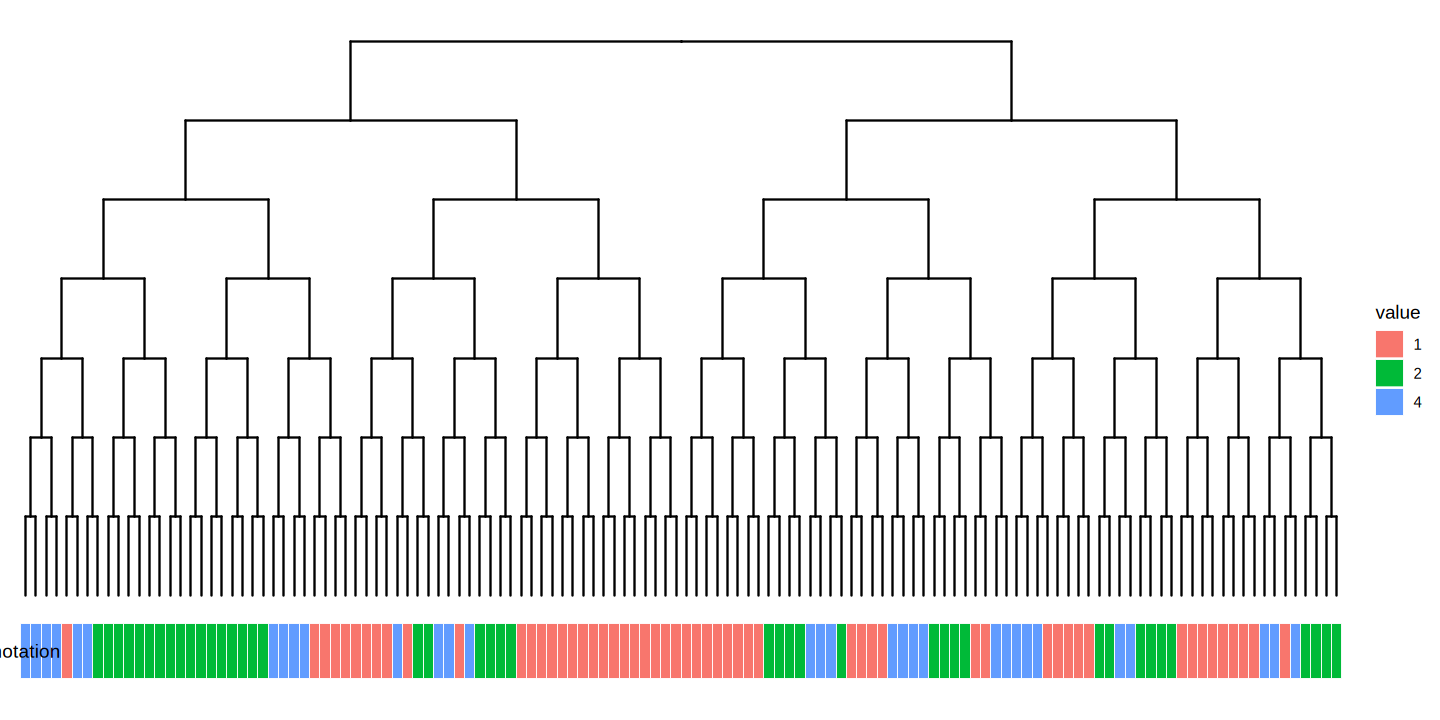

In [4]:
# Set plot dimensions for better visualization
options(repr.plot.width = 12, repr.plot.height = 6)

# Extract metadata and create annotation
meta <- sim.res$scLT$meta
annotation <- as.factor(meta$cluster)
names(annotation) <- meta$nodeID

# Create tree plot with state annotations
p <- ggtree(sim.res$scLT$tree) + layout_dendrogram()
gheatmap(p, data.frame(annotation), width = 0.1)

#### Continuous Time Tree 

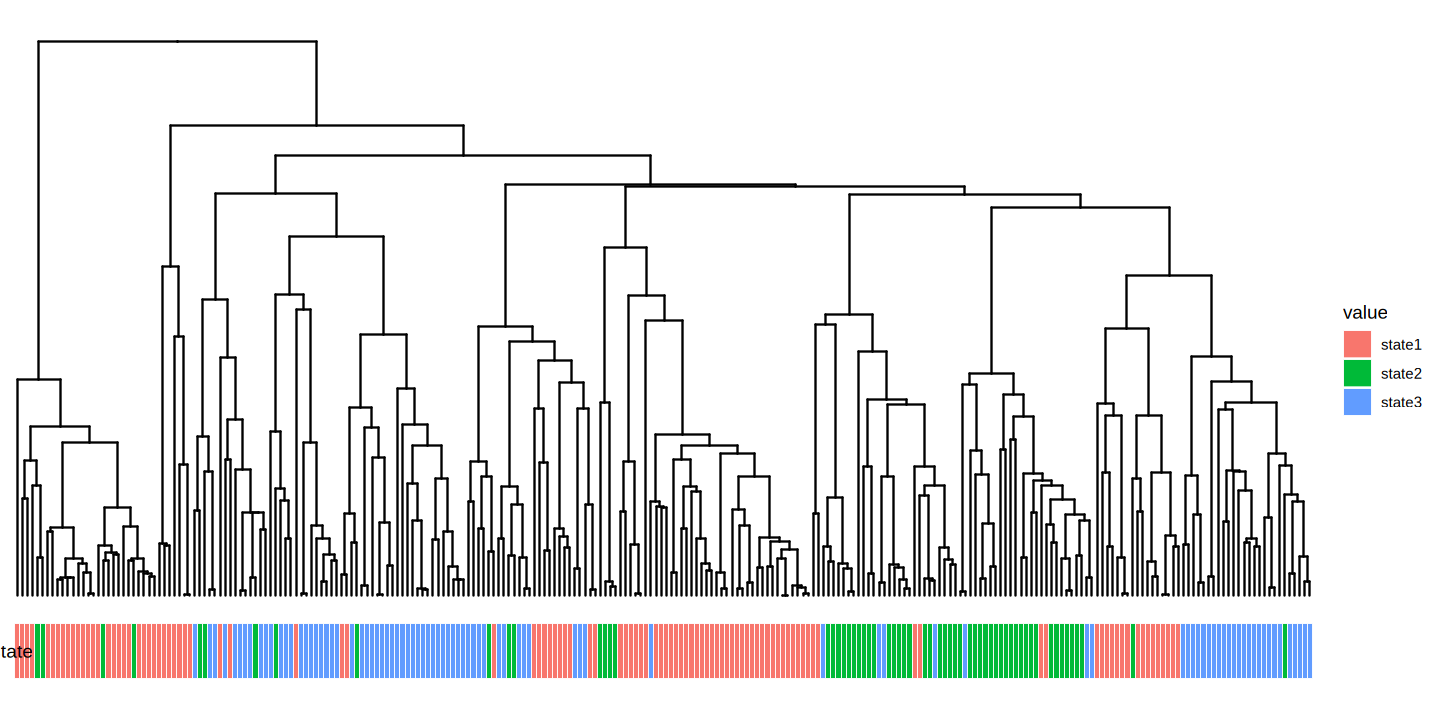

In [4]:
# Plot the tree with tip states  
options(repr.plot.width = 12, repr.plot.height = 6)
hbd_annot <- data.frame(state = hbd_tree$states, row.names = hbd_tree$tip.label)
gheatmap(ggtree(hbd_tree) + layout_dendrogram(), hbd_annot, width = 0.1)
  


## Step 3: Examine Simulated Gene Expression

The simulated expression data contains genes following different evolutionary models:
- **BM1_1 to BM1_30**: Genes evolving under Brownian Motion
- **OU1_1 to OU1_30**: Genes evolving under single-optimum OU
- **OUM_1 to OUM_30**: Genes evolving under multi-optimum OU

Each set of 30 genes represents different combinations of the α and σ parameters we specified.
The count data simulates realistic single-cell RNA-seq counts.

In [5]:
# Display the first few rows of simulated gene expression
# Notice the different patterns across BM1, OU1, and OUM genes
head(sim.res$simulated_OU$counts[[1]])

,BM1_1,BM1_2,BM1_3,BM1_4,BM1_5,BM1_6,BM1_7,BM1_8,BM1_9,BM1_10,⋯,OUM_23,OUM_24,OUM_25,OUM_26,OUM_27,OUM_28,OUM_29,OUM_30,OUM,species
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<chr>
1,333,165,24,490,5,880,275,848,0,19,⋯,496,314,239,439,1248,0,396,17,4,t1
2,453,219,64,444,24,961,521,815,17,4,⋯,455,226,88,293,967,0,186,2,4,t2
3,528,380,49,599,68,649,272,558,4,8,⋯,420,312,177,358,1423,0,298,140,4,t3
4,1466,352,16,701,8,567,128,831,0,12,⋯,539,355,203,473,910,0,619,0,4,t4
5,483,57,63,540,0,575,322,757,62,2,⋯,510,459,165,579,1671,0,166,95,1,t5
6,224,157,68,634,0,255,1211,780,0,40,⋯,423,287,107,261,1133,0,0,13,4,t6


## Next Steps: Running SCOUT on Simulated Data
First, `formatSCOUT` prepares the data for analysis with the core function in the model `runSCOUT`. This produces an rds file with annotations and further post-processing is needed to extract gene names and annotations. The wrapper function `SCOUT` runs all steps and returns a table with genes and annotations, as well as $\alpha$ and $\sigma^2$ parameter estimates. Since, $\theta$ estimates differ by model, those are returned separately. 

**Key parameters**: 
* *counts.file* | Path to counts file with OUx annotations for any non-BM/OU1 hypotheses. Key columns: 'species' (or specify the column name with the tip-labels with the argument 'species_key'), OUx, genes. 
* *tree.file* | Path to tree newick file. Tip labels should match counts file.
*  *results.dir* | Output path. SCOUT writes results to this directory.
*   *regimes* | Regimes of interest. Defaults to BM, recommended to run BM1, OU1, and OUX. 
* *blacklist* | Test genes are automatically inferred from the column names in the counts file. If there are any columns that are not either the species identifier or an OUX model, list here to avoid being considered a 'gene'.
* *method* | EM (full EM model), SM (smoothing model), MTF (tip fog model). Default is EM.
* *normalize* | Boolean whether to normalize counts. Set to FALSE if already normalized.
* *scale_tree* | Boolean whether to scale the tree height to 1. Recommended for small branch length trees.
*  **Model-Specific Parameters**
    - smoothing_k | (int) default = 8, higher values reads in information from farther away leaves.
    - tau_prior_sd and tau_prior_mean | [0, 1] control on the tau prior for the EM model. Recommended < 0.4.
    - fixed.root | whether the root is estimated or 'absorbed' into the initial regime (not estimated). Default is fixed.
    - lambda1 and lambda2 | [0,1] how much weight to place on the priors. Both should be non-zero for best performance. Both default to 0.2


In [4]:
library(SCOUT)

In [8]:
# make the output directory if it doesn't exist
dir.create("./scout_output", recursive = TRUE, showWarnings = FALSE)

scout.res <- SCOUT(counts.file = './simulate_data/sim_test_alpha_1_sigma_1_OUEVF_counts.csv',
      tree.file   = './simulate_data/sim_test_newick.nwk',
      results_dir = "./scout_output",
      regimes     = c('BM1', 'OU1', 'OUM'),
      testid      = '3state_default',
      selection_ic  = 'AICc',
      cores   = 32, 
      logfile = './scout_output/3state_default.log',
      verbose = TRUE
  )   


Directory already exists: ./scout_output 


2026-10-02 15:33:13.141461 | Started logging @ ./scout_output/3state_default.log

2026-10-02 15:33:13.143876 | Data will be saved to --> ./scout_output

2026-10-02 15:33:13.150669 | =========================================================


2026-10-02 15:33:13.172673 | Inferring gene list from input data columns.

2026-10-02 15:33:13.177315 | 90 genes were detected. 

2026-10-02 15:33:13.196381 | 128 leaves were found in the raw tree. 128 leaves intersect with species column.

2026-10-02 15:33:13.202973 | Preprocessing tree

2026-10-02 15:33:13.20435 | Found edge lengths.

2026-10-02 15:33:13.205673 | 2026-10-02 15:33:13.205678 Log normalizing gene expression counts.

2026-10-02 15:33:13.21243 | Regime: BM1 Rcol: OU1 Model: BM1

2026-10-02 15:33:13.213802 | Regime: OU1 Rcol: OU1 Model: OU1

2026-10-02 15:33:13.295835 | Regime: OUM Rcol: OUM Model: OUM



Running 270 combinations. Results will be saved at run ID = 3state_default 


2026-10-02 15:33:23.940684 | Start time = 15:33:23


2026-10-02 15:36:51.062522 | End time = 15:36:51


2026-10-02 15:36:51.815419 | Done with initial analysis of 3state_default.

2026-10-02 15:36:51.822258 | =========================================================


2026-10-02 15:36:51.827432 | Processsing Results... Saving files to ./scout_output

2026-10-02 15:36:53.16453 | Model selection (AICc + hybrid LRT): 86 of 90 genes in final_set.



## Now we can look at the classifications for each gene and the scores:

In [12]:
scout.res$SCOUT_selection$truth <-  gsub('_\\d+', '', scout.res$SCOUT_selection$gene_name)
head(scout.res$SCOUT_selection)

table(scout.res$SCOUT_selection$truth, scout.res$SCOUT_selection$selected_regime)

,dataset,gene_name,selected_regime,selected_model,next_best_regime,AICc,AICc_weight,delta_AICc_next,ll_total,param.count,⋯,lrt_p_corrected,flag_not_converged,flag_max_iter,flag_oscillating,flag_ambiguous,flag_missing_fit,lrt_p_fdr,final_set,ic,truth
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<dbl>,<lgl>,<chr>,<chr>
1,3state_default,BM1_1,BM1,BM1,OU1,445.9208,0.9999991,28.290459,-219.86361,3,⋯,NA,FALSE,FALSE,FALSE,FALSE,FALSE,NA,TRUE,AICc,BM1
2,3state_default,BM1_10,OUM,OUM,OU1,272.4796,0.9980732,12.520608,-129.89268,6,⋯,0.0002150135,FALSE,FALSE,FALSE,FALSE,FALSE,0.0002956436,TRUE,AICc,BM1
3,3state_default,BM1_11,BM1,BM1,OU1,303.7666,0.9999984,27.431498,-148.78652,3,⋯,NA,FALSE,FALSE,FALSE,FALSE,FALSE,NA,TRUE,AICc,BM1
4,3state_default,BM1_12,BM1,BM1,OU1,190.0239,0.9999559,20.262341,-91.91516,3,⋯,NA,FALSE,FALSE,FALSE,FALSE,FALSE,NA,TRUE,AICc,BM1
5,3state_default,BM1_13,BM1,BM1,OU1,285.2605,0.9985881,13.420290,-139.53348,3,⋯,NA,FALSE,FALSE,FALSE,FALSE,FALSE,NA,TRUE,AICc,BM1
6,3state_default,BM1_14,OU1,OU1,BM1,467.3641,0.6888208,2.299511,-229.51944,4,⋯,NA,FALSE,FALSE,FALSE,FALSE,FALSE,NA,TRUE,AICc,BM1


     
      BM1 OU1 OUM
  BM1  24   5   1
  OU1   1  27   2
  OUM   1   2  27

In [11]:
purrr::map(scout.res$SCOUT_params, head)

,gene_name,tau,alpha,sigma,theta_1
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,BM1_1,0.4077340,1e-10,0.6130655,5.550174
2,BM1_2,0.5246162,1e-10,0.5455308,4.902696
3,BM1_3,0.2335512,1e-10,0.2854033,3.900953
4,BM1_4,0.1329938,1e-10,0.1104755,6.030565
5,BM1_5,0.3696296,1e-10,1.0025274,2.155424
6,BM1_6,0.1816764,1e-10,0.1088616,6.927260
,gene_name,tau,alpha,sigma,theta_1
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,BM1_1,0.4053486,0.3307233,1.6834786,5.550074
